<a href="https://colab.research.google.com/github/SHREYA-G-AMIN/Agentic-AI/blob/main/Day_02_Hands_On_5_AI_Ready_Data_Analyzer_Main_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hands-on 5: Main Project — Sales and Product Data Analyzer

**Topic:** Complete CSV and API application  
**Level:** Beginner to intermediate  
**Time:** 55–60 minutes

## Scenario

An online shop has local sales data in a CSV file. It also needs product
rating, brand and stock information from a public API.

Build one simple application that:

1. Loads and cleans sales data.
2. Gets product data from an API.
3. Uses a fallback CSV when the API fails.
4. Combines both tables.
5. Calculates revenue.
6. Creates and saves a final summary.

## Step 1: Create the CSV datasets

In [ ]:
from pathlib import Path

Path("sales_data.csv").write_text(
    'order_id,order_date,product_id,product_name,category,price,quantity,payment_status\nO101,2026-08-01,1,Mascara, beauty ,799,2,Paid\nO102,2026-08-02,2,Eye Shadow,BEAUTY,1599,1,Paid\nO103,2026-08-03,3,Face Powder,Beauty,1199,3,Paid\nO104,2026-08-04,4,Lipstick,beauty,999,2,Pending\nO104,2026-08-04,4,Lipstick,beauty,999,2,Pending\nO105,2026-08-05,5,Nail Polish,BEAUTY,699,4,Paid\nO106,2026-08-06,6,CK One Perfume,fragrance,3999,1,Paid\nO107,2026-08-07,7,Coco Noir,Fragrances,,1,Paid\nO108,2026-08-08,8,Dior Jadore,FRAGRANCES,7499,1,Paid\nO109,2026-08-09,9,Dolce Shine,fragrance,5999,-1,Paid\nO110,2026-08-10,10,Gucci Bloom,Fragrances,6499,2,Failed\nO111,2026-08-11,1,Mascara,Beauty,849,2,Paid\n',
    encoding="utf-8"
)

Path("products_fallback.csv").write_text(
    'product_id,title,brand,category,api_price,rating,stock\n1,Essence Mascara Lash Princess,Essence,beauty,9.99,4.94,5\n2,Eyeshadow Palette with Mirror,Glamour Beauty,beauty,19.99,4.28,44\n3,Powder Canister,Velvet Touch,beauty,14.99,3.82,59\n4,Red Lipstick,Chic Cosmetics,beauty,12.99,4.51,68\n5,Red Nail Polish,Nail Couture,beauty,8.99,3.91,71\n6,Calvin Klein CK One,Calvin Klein,fragrances,49.99,4.85,17\n7,Chanel Coco Noir Eau De,Chanel,fragrances,129.99,4.26,41\n8,Dior Jadore,Dior,fragrances,89.99,4.31,91\n9,Dolce Shine Eau de,Dolce and Gabbana,fragrances,69.99,3.77,3\n10,Gucci Bloom Eau de,Gucci,fragrances,79.99,4.69,93\n',
    encoding="utf-8"
)

print("CSV datasets created.")

CSV datasets created.


## Step 2: Load the sales CSV

In [ ]:
import pandas as pd
import requests
import matplotlib.pyplot as plt

sales = pd.read_csv("sales_data.csv")

print("Raw sales data:")
print(sales.head().to_string(index=False))

Raw sales data:
order_id order_date  product_id product_name category  price  quantity payment_status
    O101 2026-08-01           1      Mascara  beauty   799.0         2           Paid
    O102 2026-08-02           2   Eye Shadow   BEAUTY 1599.0         1           Paid
    O103 2026-08-03           3  Face Powder   Beauty 1199.0         3           Paid
    O104 2026-08-04           4     Lipstick   beauty  999.0         2        Pending
    O104 2026-08-04           4     Lipstick   beauty  999.0         2        Pending


## Step 3: Clean the sales data

In [ ]:
clean_sales = sales.drop_duplicates(
    subset="order_id"
).copy()

clean_sales["category"] = (
    clean_sales["category"]
    .str.strip()
    .str.title()
    .replace({"Fragrance": "Fragrances"})
)

clean_sales = clean_sales[
    clean_sales["quantity"] > 0
].copy()

print(clean_sales.to_string(index=False))

order_id order_date  product_id   product_name   category  price  quantity payment_status
    O101 2026-08-01           1        Mascara     Beauty  799.0         2           Paid
    O102 2026-08-02           2     Eye Shadow     Beauty 1599.0         1           Paid
    O103 2026-08-03           3    Face Powder     Beauty 1199.0         3           Paid
    O104 2026-08-04           4       Lipstick     Beauty  999.0         2        Pending
    O105 2026-08-05           5    Nail Polish     Beauty  699.0         4           Paid
    O106 2026-08-06           6 CK One Perfume Fragrances 3999.0         1           Paid
    O107 2026-08-07           7      Coco Noir Fragrances    NaN         1           Paid
    O108 2026-08-08           8    Dior Jadore Fragrances 7499.0         1           Paid
    O110 2026-08-10          10    Gucci Bloom Fragrances 6499.0         2         Failed
    O111 2026-08-11           1        Mascara     Beauty  849.0         2           Paid


## Step 4: Get product data from the API

In [ ]:
# Try to fetch product data from the Live API
try:

    # Send a GET request to the DummyJSON Products API
    response = requests.get(
        "https://dummyjson.com/products",

        # Request only 10 products from the API
        params={"limit": 10},

        # Wait maximum 10 seconds for the API response
        timeout=10
    )

    # Check whether the API request was successful
    # If there is an HTTP error (404, 500, etc.), an exception is raised
    response.raise_for_status()

    # Convert the API response from JSON format into a Python dictionary
    api_data = response.json()

    # Extract the "products" list from the API response
    # and convert it into a Pandas DataFrame
    products = pd.DataFrame(api_data["products"])

    # Select only the required columns from the API data
    products = products[
        ["id", "title", "brand", "category", "price", "rating", "stock"]
    ]

    # Rename columns to make them more meaningful
    products = products.rename(
        columns={
            "id": "product_id",
            "price": "api_price",
            "category": "api_category"
        }
    )

    # Store the source of the data
    data_source = "Live API"


# If the API request fails or JSON processing fails,
# execute the fallback section
except (requests.RequestException, ValueError) as error:

    # Load product data from the local CSV file
    products = pd.read_csv("products_fallback.csv")

    # Rename the category column to match the API DataFrame
    products = products.rename(
        columns={
            "category": "api_category"
        }
    )

    # Store the source of the data
    data_source = "Fallback CSV"

    # Display the type of error that occurred
    print("API error:", type(error).__name__)


# Display whether the data came from the API or fallback CSV
print("Product data source:", data_source)

# Display the first 5 rows of the product data
# index=False removes the DataFrame index from the output
print(products.head().to_string(index=False))

Product data source: Live API
 product_id                         title          brand api_category  api_price  rating  stock
          1 Essence Mascara Lash Princess        Essence       beauty       9.99    2.56     99
          2 Eyeshadow Palette with Mirror Glamour Beauty       beauty      19.99    2.86     34
          3               Powder Canister   Velvet Touch       beauty      14.99    4.64     89
          4                  Red Lipstick Chic Cosmetics       beauty      12.99    4.36     91
          5               Red Nail Polish   Nail Couture       beauty       8.99    4.32     79


## Step 5: Combine sales and product data

product_id is the common column in both tables.

In [ ]:
final_data = clean_sales.merge(
    products[
        [
            "product_id",
            "title",
            "brand",
            "api_category",
            "api_price",
            "rating",
            "stock"
        ]
    ],
    on="product_id",
    how="left"
)

print(final_data.head().to_string(index=False))

order_id order_date  product_id product_name category  price  quantity payment_status                         title          brand api_category  api_price  rating  stock
    O101 2026-08-01           1      Mascara   Beauty  799.0         2           Paid Essence Mascara Lash Princess        Essence       beauty       9.99    2.56     99
    O102 2026-08-02           2   Eye Shadow   Beauty 1599.0         1           Paid Eyeshadow Palette with Mirror Glamour Beauty       beauty      19.99    2.86     34
    O103 2026-08-03           3  Face Powder   Beauty 1199.0         3           Paid               Powder Canister   Velvet Touch       beauty      14.99    4.64     89
    O104 2026-08-04           4     Lipstick   Beauty  999.0         2        Pending                  Red Lipstick Chic Cosmetics       beauty      12.99    4.36     91
    O105 2026-08-05           5  Nail Polish   Beauty  699.0         4           Paid               Red Nail Polish   Nail Couture       beauty       

## Step 6: Fill the missing sale price and calculate revenue

If the local sale price is missing, the API price is used.

In [ ]:
final_data["price"] = final_data["price"].fillna(
    final_data["api_price"]
)

final_data["revenue"] = (
    final_data["price"] * final_data["quantity"]
)

final_data["stock_status"] = "Available"
final_data.loc[
    final_data["stock"] < 10,
    "stock_status"
] = "Low Stock"

print(
    final_data[
        [
            "order_id",
            "product_name",
            "brand",
            "price",
            "quantity",
            "revenue",
            "rating",
            "stock_status"
        ]
    ].to_string(index=False)
)

order_id   product_name          brand   price  quantity  revenue  rating stock_status
    O101        Mascara        Essence  799.00         2  1598.00    2.56    Available
    O102     Eye Shadow Glamour Beauty 1599.00         1  1599.00    2.86    Available
    O103    Face Powder   Velvet Touch 1199.00         3  3597.00    4.64    Available
    O104       Lipstick Chic Cosmetics  999.00         2  1998.00    4.36    Available
    O105    Nail Polish   Nail Couture  699.00         4  2796.00    4.32    Available
    O106 CK One Perfume   Calvin Klein 3999.00         1  3999.00    4.37    Available
    O107      Coco Noir         Chanel  129.99         1   129.99    4.26    Available
    O108    Dior Jadore           Dior 7499.00         1  7499.00    3.80    Available
    O110    Gucci Bloom          Gucci 6499.00         2 12998.00    2.74    Available
    O111        Mascara        Essence  849.00         2  1698.00    2.56    Available


## Step 7: Create the final category summary

In [ ]:
final_summary = (
    final_data.groupby("category")
    .agg(
        total_orders=("order_id", "count"),
        total_quantity=("quantity", "sum"),
        total_revenue=("revenue", "sum"),
        average_rating=("rating", "mean")
    )
    .reset_index()
)

final_summary["average_rating"] = (
    final_summary["average_rating"].round(2)
)

print(final_summary.to_string(index=False))

  category  total_orders  total_quantity  total_revenue  average_rating
    Beauty             6              14       13286.00            3.55
Fragrances             4               5       24625.99            3.79


## Step 8: Create a simple chart

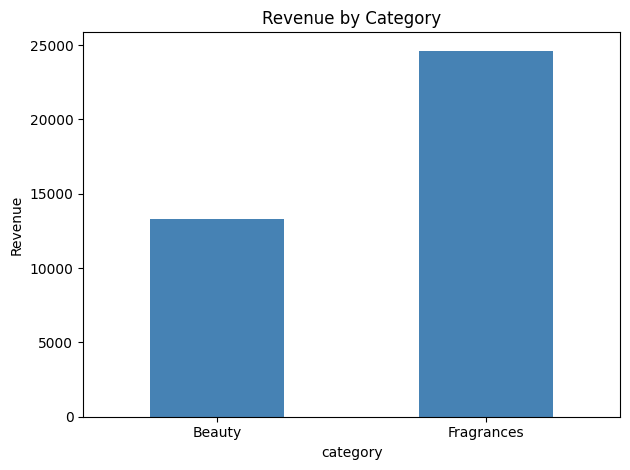

Created: revenue_chart.png


In [ ]:
final_summary.plot(
    x="category",
    y="total_revenue",
    kind="bar",
    color="steelblue",
    legend=False,
    title="Revenue by Category"
)

plt.ylabel("Revenue")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("revenue_chart.png")
plt.show()

print("Created: revenue_chart.png")

## Step 9: Save the final files

In [ ]:
final_data.to_csv(
    "final_sales_report.csv",
    index=False
)

final_summary.to_csv(
    "final_category_summary.csv",
    index=False
)

print("Created: final_sales_report.csv")
print("Created: final_category_summary.csv")

Created: final_sales_report.csv
Created: final_category_summary.csv


## Step 10: Display the main result

In [ ]:
total_revenue = final_data["revenue"].sum()

top_category = final_summary.sort_values(
    "total_revenue",
    ascending=False
).iloc[0]

print("Total revenue: ₹{:,.2f}".format(total_revenue))
print(
    "Top category:",
    top_category["category"]
)
print("Product data source:", data_source)

Total revenue: ₹37,911.99
Top category: Fragrances
Product data source: Live API


## Student extension

1. Display only Paid orders.
2. Create a report containing only Low Stock products.
3. Find the top three products by revenue.
4. Add a new category to sales_data.csv and run the project again.

## Expected learning

You can now build a complete application using a CSV dataset, Pandas,
a public API, JSON, error handling, merging, analysis and CSV output.